# NexusBots — LLM Baseline Benchmark

Evaluates **6 large LLMs** on the same 100-row test set and same Enhanced System Prompt  
used by our Qwen3-0.6B system — to provide a fair apples-to-apples comparison.

| Model | Provider | Tier |
|---|---|---|
| `gpt-4o` | OpenAI | Best quality |
| `gpt-4o-mini` | OpenAI | Fast / cheap |
| `claude-sonnet-4-6` | Anthropic | Best quality |
| `claude-haiku-4-5-20251001` | Anthropic | Fast / cheap |
| `gemini-1.5-pro` | Google | Best quality |
| `gemini-1.5-flash` | Google | Fast / cheap |

**Metrics:** Tool Accuracy · Arg F1 · UI Guide Accuracy · p50 Latency · API Cost  
**Dataset:** `finetune/data/test.jsonl` — same 100 held-out rows used in Qwen benchmark

---
### Before running
Set your API keys in **Cell 3**. Models with missing keys are automatically skipped — you can run with just the providers you have.

## Cell 1 — Install dependencies

In [ ]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

pip("openai>=1.30", "anthropic>=0.28", "google-generativeai>=0.7",
    "pandas", "matplotlib", "tabulate", "tiktoken")
print("All packages ready.")

All packages ready.


## Cell 2 — Imports & paths

In [ ]:
import json, os, re, sys, time, warnings
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(".").resolve()          # finetune/eval/
FINETUNE_ROOT = NOTEBOOK_DIR.parent          # finetune/
PROJECT_ROOT  = FINETUNE_ROOT.parent         # NexusBots-TDL-Project/

TEST_PATH   = FINETUNE_ROOT / "data" / "test.jsonl"
RESULTS_DIR = PROJECT_ROOT / "research" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(FINETUNE_ROOT))

assert TEST_PATH.exists(), f"Test file not found: {TEST_PATH}"
print(f"Project root : {PROJECT_ROOT}")
print(f"Test set     : {TEST_PATH}")
print(f"Results dir  : {RESULTS_DIR}")

Project root : /home/cs412/Downloads/Subjects/TDL/NexusBots-TDL-Project
Test set     : /home/cs412/Downloads/Subjects/TDL/NexusBots-TDL-Project/finetune/data/test.jsonl
Results dir  : /home/cs412/Downloads/Subjects/TDL/NexusBots-TDL-Project/research/results


## Cell 3 — API keys  ← ADD YOUR KEYS HERE

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  FILL IN YOUR API KEYS BELOW
#  Leave as empty string "" to skip that provider
# ─────────────────────────────────────────────────────────────────

OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY",    "")   # sk-...
# ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")   # sk-ant-...
GOOGLE_API_KEY    = os.getenv("GOOGLE_API_KEY",    "sk_0z46mppl_CavCBcjFZC9zhyNEWp5qsOlJ")   # AI...

# ─────────────────────────────────────────────────────────────────
#  Model definitions
#  Each entry: (label, provider, model_id, input_cost_per_1M, output_cost_per_1M)
#  Costs in USD as of 2025 — update if pricing changes
# ─────────────────────────────────────────────────────────────────
ALL_MODELS = [
    # label                        provider     model_id                        $/1M in   $/1M out
    ("GPT-4o",                     "openai",    "gpt-4o",                       5.00,     15.00),
    ("GPT-4o-mini",                "openai",    "gpt-4o-mini",                  0.15,      0.60),
    ("Claude Sonnet 4.6",          "anthropic", "claude-sonnet-4-6",            3.00,     15.00),
    ("Claude Haiku 4.5",           "anthropic", "claude-haiku-4-5-20251001",    0.80,      4.00),
    ("Gemini 1.5 Pro",             "google",    "gemini-1.5-pro",               3.50,     10.50),
    ("Gemini 1.5 Flash",           "google",    "gemini-1.5-flash",             0.075,     0.30),
]

# Auto-filter models based on available keys
ACTIVE_MODELS = []
for entry in ALL_MODELS:
    provider = entry[1]
    if provider == "openai"    and OPENAI_API_KEY:    ACTIVE_MODELS.append(entry)
    elif provider == "anthropic" and ANTHROPIC_API_KEY: ACTIVE_MODELS.append(entry)
    elif provider == "google"    and GOOGLE_API_KEY:    ACTIVE_MODELS.append(entry)

print(f"Keys present  : "
      f"OpenAI={'YES' if OPENAI_API_KEY else 'NO'}  "
      f"Anthropic={'YES' if ANTHROPIC_API_KEY else 'NO'}  "
      f"Google={'YES' if GOOGLE_API_KEY else 'NO'}")
print(f"Active models : {len(ACTIVE_MODELS)} / {len(ALL_MODELS)}")
for m in ACTIVE_MODELS:
    print(f"  ✓  {m[0]:<28}  ({m[2]})")
if len(ACTIVE_MODELS) == 0:
    print("\n  ⚠  No API keys set — add keys above and re-run this cell.")

Keys present  : OpenAI=NO  Anthropic=NO  Google=YES
Active models : 2 / 6
  ✓  Gemini 1.5 Pro                (gemini-1.5-pro)
  ✓  Gemini 1.5 Flash              (gemini-1.5-flash)


## Cell 4 — Load Enhanced System Prompt + test dataset

In [ ]:
from eval.enhanced_prompt import ENHANCED_SYSTEM_PROMPT

SYSTEM_PROMPT = ENHANCED_SYSTEM_PROMPT

rows = [json.loads(line) for line in TEST_PATH.open() if line.strip()]
print(f"System prompt : {len(SYSTEM_PROMPT):,} chars")
print(f"Test rows     : {len(rows)}")

# Quick dataset breakdown
tools = defaultdict(int)
langs = defaultdict(int)
for r in rows:
    tools[r.get("tool_name", "?")]   += 1
    langs[r.get("language",  "?")]   += 1

print("\nTool distribution:")
for t, c in sorted(tools.items(), key=lambda x: -x[1]):
    print(f"  {t:<25} {c:>3}")
print("\nLanguage distribution:")
for l, c in sorted(langs.items()):
    print(f"  {l.upper():<6} {c:>3}")

System prompt : 5,522 chars
Test rows     : 100

Tool distribution:
  navigate_to                27
  search_products            25
  recommend                  16
  get_product                11
  add_to_cart                11
  compare_products           10

Language distribution:
  EN      55
  HI      27
  TE      18


## Cell 5 — Helper functions (shared across all providers)

In [ ]:
VALID_TOOLS = {
    "search_products", "get_product", "compare_products",
    "recommend", "add_to_cart", "navigate_to",
}


def parse_json(text: str) -> dict:
    """Robustly extract JSON from LLM output."""
    if not text:
        return {}
    # Strip markdown fences
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text.strip(), flags=re.MULTILINE).strip()
    # Direct parse
    try:
        return json.loads(text)
    except Exception:
        pass
    # Find outermost braces
    s, e = text.find("{"), text.rfind("}") + 1
    if s >= 0 and e > s:
        try:
            return json.loads(text[s:e])
        except Exception:
            pass
    return {}


def extract_gold(row: dict):
    """Return (gold_tool, gold_args, gold_guide) from a test row."""
    for msg in row.get("messages", []):
        if msg["role"] == "assistant":
            obj = json.loads(msg["content"])
            return obj["tool"], obj.get("arguments", {}), obj.get("ui_guide")
    return "", {}, None


def extract_query_context(row: dict):
    """Return (query_string, context_string) from user message."""
    user_msg = next(
        (m["content"] for m in row["messages"] if m["role"] == "user"), ""
    )
    parts = user_msg.split("\nContext: ", 1)
    q   = parts[0].replace("Query: ", "").strip()
    ctx = parts[1].strip() if len(parts) > 1 else "{}"
    return q, ctx


def score_arg_f1(pred: dict, gold: dict) -> float:
    """Field-level F1 between predicted and gold arguments."""
    if not gold:
        return 1.0 if not pred else 0.0
    keys = set(gold) | set(pred)
    if not keys:
        return 1.0
    hits = sum(
        str(pred.get(k, "")).strip().lower() == str(gold.get(k, "")).strip().lower()
        for k in keys
    )
    return hits / len(keys)


def estimate_tokens(text: str) -> int:
    """Rough token count: ~4 chars per token."""
    return max(1, len(text) // 4)


print("Helper functions defined.")

Helper functions defined.


## Cell 6 — Provider clients

In [ ]:
# ── OpenAI ─────────────────────────────────────────────────────────────────────
_openai_client = None
if OPENAI_API_KEY:
    from openai import OpenAI
    _openai_client = OpenAI(api_key=OPENAI_API_KEY)
    print("OpenAI client  : ready")


def call_openai(model_id: str, query: str, ctx: str) -> tuple[str, int, int]:
    """Returns (raw_text, input_tokens, output_tokens)."""
    resp = _openai_client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"Query: {query}\nContext: {ctx}"},
        ],
        temperature=0,
        max_tokens=200,
    )
    text = resp.choices[0].message.content or ""
    return text, resp.usage.prompt_tokens, resp.usage.completion_tokens


# ── Anthropic ──────────────────────────────────────────────────────────────────
_anthropic_client = None
if ANTHROPIC_API_KEY:
    import anthropic as _anthropic_sdk
    _anthropic_client = _anthropic_sdk.Anthropic(api_key=ANTHROPIC_API_KEY)
    print("Anthropic client: ready")


def call_anthropic(model_id: str, query: str, ctx: str) -> tuple[str, int, int]:
    """Returns (raw_text, input_tokens, output_tokens)."""
    resp = _anthropic_client.messages.create(
        model=model_id,
        system=SYSTEM_PROMPT,
        messages=[
            {"role": "user", "content": f"Query: {query}\nContext: {ctx}"},
        ],
        temperature=0,
        max_tokens=200,
    )
    text = resp.content[0].text if resp.content else ""
    return text, resp.usage.input_tokens, resp.usage.output_tokens


# ── Google Gemini ──────────────────────────────────────────────────────────────
_gemini_models = {}
if GOOGLE_API_KEY:
    import google.generativeai as genai
    genai.configure(api_key=GOOGLE_API_KEY)
    print("Google client  : ready")


def call_gemini(model_id: str, query: str, ctx: str) -> tuple[str, int, int]:
    """Returns (raw_text, input_tokens, output_tokens)."""
    import google.generativeai as genai
    if model_id not in _gemini_models:
        _gemini_models[model_id] = genai.GenerativeModel(
            model_name=model_id,
            system_instruction=SYSTEM_PROMPT,
            generation_config=genai.GenerationConfig(
                temperature=0,
                max_output_tokens=200,
            ),
        )
    mdl  = _gemini_models[model_id]
    resp = mdl.generate_content(f"Query: {query}\nContext: {ctx}")
    text = resp.text if hasattr(resp, "text") else ""
    # Gemini may not return token counts in all SDK versions
    try:
        in_tok  = resp.usage_metadata.prompt_token_count
        out_tok = resp.usage_metadata.candidates_token_count
    except Exception:
        in_tok  = estimate_tokens(SYSTEM_PROMPT + query + ctx)
        out_tok = estimate_tokens(text)
    return text, in_tok, out_tok


# ── Unified dispatch ───────────────────────────────────────────────────────────
def call_model(provider: str, model_id: str, query: str, ctx: str):
    """Returns (raw_text, input_tokens, output_tokens)."""
    if provider == "openai":
        return call_openai(model_id, query, ctx)
    elif provider == "anthropic":
        return call_anthropic(model_id, query, ctx)
    elif provider == "google":
        return call_gemini(model_id, query, ctx)
    raise ValueError(f"Unknown provider: {provider}")


print("\nAll provider clients initialised.")

Google client  : ready

All provider clients initialised.


## Cell 7 — Cost estimator (dry run — no API calls)

In [ ]:
# Estimate tokens for a single call
sample_q, sample_ctx = extract_query_context(rows[0])
user_content  = f"Query: {sample_q}\nContext: {sample_ctx}"
avg_in_tokens = estimate_tokens(SYSTEM_PROMPT + user_content)
avg_out_tokens = 60  # typical JSON output

print(f"Estimated tokens per call:")
print(f"  Input  : ~{avg_in_tokens:,} tokens  (system prompt + query + context)")
print(f"  Output : ~{avg_out_tokens} tokens   (JSON response)")
print()
print(f"{'Model':<28}  {'$/100 calls':>12}  {'$/1000 calls':>13}")
print("-" * 58)
for label, provider, model_id, in_cost, out_cost in ALL_MODELS:
    cost_100 = (avg_in_tokens * in_cost + avg_out_tokens * out_cost) / 1_000_000 * 100
    cost_1k  = cost_100 * 10
    marker = " ← active" if any(m[0] == label for m in ACTIVE_MODELS) else ""
    print(f"  {label:<26}  ${cost_100:>10.4f}   ${cost_1k:>11.3f}{marker}")

total_active = sum(
    (avg_in_tokens * m[3] + avg_out_tokens * m[4]) / 1_000_000 * len(rows)
    for m in ACTIVE_MODELS
)
print(f"\n  Total estimated cost to run all active models on {len(rows)} rows: ${total_active:.4f}")

Estimated tokens per call:
  Input  : ~1,433 tokens  (system prompt + query + context)
  Output : ~60 tokens   (JSON response)

Model                          $/100 calls   $/1000 calls
----------------------------------------------------------
  GPT-4o                      $    0.8065   $      8.065
  GPT-4o-mini                 $    0.0251   $      0.251
  Claude Sonnet 4.6           $    0.5199   $      5.199
  Claude Haiku 4.5            $    0.1386   $      1.386
  Gemini 1.5 Pro              $    0.5645   $      5.646 ← active
  Gemini 1.5 Flash            $    0.0125   $      0.125 ← active

  Total estimated cost to run all active models on 100 rows: $0.5771


## Cell 8 — Evaluation loop (single model)

In [ ]:
RETRY_DELAY = 2   # seconds between retries on rate limit
MAX_RETRIES = 3


def evaluate_model(label, provider, model_id, in_cost_per_1m, out_cost_per_1m):
    """
    Run evaluation for one LLM on the full test set.
    Returns (records, fails, cost_usd).
    """
    stats   = defaultdict(lambda: {"ok": 0, "f1": 0.0, "guide_ok": 0, "n": 0, "lats": []})
    records = []
    fails   = []
    total_ok = 0
    total_in_tok  = 0
    total_out_tok = 0
    n = len(rows)

    print(f"\n{'='*68}")
    print(f"  {label}  ({model_id})")
    print(f"{'='*68}")

    for i, row in enumerate(rows):
        gold_tool, gold_args, gold_guide = extract_gold(row)
        q, ctx = extract_query_context(row)
        lang   = row.get("language", "en")

        raw_text = ""
        lat_ms   = 0.0
        in_tok = out_tok = 0

        for attempt in range(MAX_RETRIES):
            try:
                t0 = time.perf_counter()
                raw_text, in_tok, out_tok = call_model(provider, model_id, q, ctx)
                lat_ms = (time.perf_counter() - t0) * 1000
                break
            except Exception as ex:
                err = str(ex)
                if attempt < MAX_RETRIES - 1 and any(
                    kw in err.lower() for kw in ["rate", "limit", "quota", "overload", "529"]
                ):
                    wait = RETRY_DELAY * (attempt + 1)
                    print(f"    ⚠  rate limit on row {i+1}, retrying in {wait}s...", flush=True)
                    time.sleep(wait)
                else:
                    print(f"    ✗  row {i+1} error: {err[:80]}", flush=True)
                    raw_text = ""
                    break

        pred       = parse_json(raw_text)
        pred_tool  = pred.get("tool", "")
        pred_args  = pred.get("arguments", {}) if isinstance(pred.get("arguments"), dict) else {}
        pred_guide = pred.get("ui_guide")

        ok       = int(pred_tool == gold_tool)
        f1       = score_arg_f1(pred_args, gold_args)
        guide_ok = int(pred_guide == gold_guide)
        total_ok += ok
        total_in_tok  += in_tok
        total_out_tok += out_tok

        stats[lang]["ok"]       += ok
        stats[lang]["f1"]       += f1
        stats[lang]["guide_ok"] += guide_ok
        stats[lang]["n"]        += 1
        stats[lang]["lats"].append(lat_ms)

        rec = {
            "row_id":      i + 1,
            "language":    lang,
            "proficiency": row.get("proficiency", ""),
            "query":       q[:70],
            "gold_tool":   gold_tool,
            "pred_tool":   pred_tool,
            "tool_ok":     ok,
            "arg_f1":      round(f1, 4),
            "gold_guide":  gold_guide,
            "pred_guide":  pred_guide,
            "guide_ok":    guide_ok,
            "lat_ms":      round(lat_ms, 1),
            "in_tokens":   in_tok,
            "out_tokens":  out_tok,
        }
        records.append(rec)
        if not ok:
            fails.append(rec | {"raw_output": raw_text[:200]})

        bar = "█" * ((i + 1) * 25 // n) + "░" * (25 - (i + 1) * 25 // n)
        print(
            f"  [{bar}] {i+1:3d}/{n}  {'✓' if ok else '✗'}  "
            f"pred={pred_tool or '(none)':22s}  "
            f"gold={gold_tool:22s}  "
            f"acc={total_ok/(i+1):.3f}",
            flush=True,
        )

    total_cost = (
        total_in_tok  * in_cost_per_1m  / 1_000_000 +
        total_out_tok * out_cost_per_1m / 1_000_000
    )
    print(f"\n  ✔ DONE → tool_acc={total_ok/n:.4f}  cost=${total_cost:.4f}  "
          f"tokens in={total_in_tok:,} out={total_out_tok:,}\n")

    return dict(stats), records, fails, total_cost


print("evaluate_model() defined.")

evaluate_model() defined.


## Cell 9 — Run all active models

> This cell makes real API calls and incurs cost. Re-run individual models below if needed.

In [ ]:
# Results stored here: model_label → (stats, records, fails, cost)
ALL_RESULTS = {}

if not ACTIVE_MODELS:
    print("No active models — add API keys in Cell 3 and re-run.")
else:
    for label, provider, model_id, in_cost, out_cost in ACTIVE_MODELS:
        stats, records, fails, cost = evaluate_model(
            label, provider, model_id, in_cost, out_cost
        )
        ALL_RESULTS[label] = {
            "stats":    stats,
            "records":  records,
            "fails":    fails,
            "cost_usd": cost,
            "model_id": model_id,
            "provider": provider,
        }
        # Small delay between models to be polite to APIs
        time.sleep(1)

    print(f"\nAll {len(ALL_RESULTS)} models evaluated.")


  Gemini 1.5 Pro  (gemini-1.5-pro)
    ✗  row 1 error: 400 API key not valid. Please pass a valid API key. [reason: "API_KEY_INVALID"
d
  [░░░░░░░░░░░░░░░░░░░░░░░░░]   1/100  ✗  pred=(none)                  gold=search_products         acc=0.000
    ✗  row 2 error: 400 API key not valid. Please pass a valid API key. [reason: "API_KEY_INVALID"
d
  [░░░░░░░░░░░░░░░░░░░░░░░░░]   2/100  ✗  pred=(none)                  gold=get_product             acc=0.000
    ✗  row 3 error: 400 API key not valid. Please pass a valid API key. [reason: "API_KEY_INVALID"
d
  [░░░░░░░░░░░░░░░░░░░░░░░░░]   3/100  ✗  pred=(none)                  gold=navigate_to             acc=0.000
    ✗  row 4 error: 400 API key not valid. Please pass a valid API key. [reason: "API_KEY_INVALID"
d
  [█░░░░░░░░░░░░░░░░░░░░░░░░]   4/100  ✗  pred=(none)                  gold=search_products         acc=0.000
    ✗  row 5 error: 400 API key not valid. Please pass a valid API key. [reason: "API_KEY_INVALID"
d
  [█░░░░░░░░░░░░░░░

## Cell 10 — Aggregate results table

In [ ]:
def summarise(label, stats, cost_usd):
    total_ok  = sum(v["ok"]       for v in stats.values())
    total_f1  = sum(v["f1"]       for v in stats.values())
    total_gok = sum(v["guide_ok"] for v in stats.values())
    n         = sum(v["n"]        for v in stats.values())
    lats      = sorted(l for v in stats.values() for l in v["lats"] if l > 0)
    p50 = lats[len(lats) // 2]       if lats else 0.0
    p95 = lats[int(len(lats) * 0.95)] if lats else 0.0
    return {
        "system":       label,
        "tool_acc":     round(total_ok  / n, 4),
        "arg_f1":       round(total_f1  / n, 4),
        "ui_guide_acc": round(total_gok / n, 4),
        "p50_ms":       round(p50, 1),
        "p95_ms":       round(p95, 1),
        "cost_usd":     round(cost_usd, 4),
        "correct":      total_ok,
        "total":        n,
    }


summary_rows = [
    summarise(label, data["stats"], data["cost_usd"])
    for label, data in ALL_RESULTS.items()
]

# Add our Qwen baseline row (from previous benchmark — fill in your actual numbers)
QWEN_RESULT = {
    "system":       "Qwen3-0.6B + Enhanced (OURS)",
    "tool_acc":     0.79,
    "arg_f1":       0.5467,
    "ui_guide_acc": 0.52,
    "p50_ms":       1113.8,
    "p95_ms":       0.0,       # fill from benchmark_enhanced_prompt.ipynb
    "cost_usd":     0.0,       # local inference = $0
    "correct":      79,
    "total":        100,
}
summary_rows.append(QWEN_RESULT)

df = pd.DataFrame(summary_rows).sort_values("tool_acc", ascending=False).reset_index(drop=True)

print("\n" + "="*85)
print("  BENCHMARK RESULTS — LLM Baselines vs Our System")
print("="*85)
print(df[["system","tool_acc","arg_f1","ui_guide_acc","p50_ms","cost_usd","correct","total"]]
      .to_string(index=False))
print()

# Compare each LLM vs our system
our_acc = QWEN_RESULT["tool_acc"]
print("  Gap vs Our System (Qwen3-0.6B + Enhanced):")
for row in summary_rows:
    if row["system"] == QWEN_RESULT["system"]:
        continue
    delta = row["tool_acc"] - our_acc
    print(f"    {row['system']:<30}  {delta:+.4f} ({delta*100:+.1f} pts)")


  BENCHMARK RESULTS — LLM Baselines vs Our System
                      system  tool_acc  arg_f1  ui_guide_acc  p50_ms  cost_usd  correct  total
Qwen3-0.6B + Enhanced (OURS)      0.79  0.5467          0.52  1113.8       0.0       79    100
              Gemini 1.5 Pro      0.00  0.0000          0.27     0.0       0.0        0    100
            Gemini 1.5 Flash      0.00  0.0000          0.27     0.0       0.0        0    100

  Gap vs Our System (Qwen3-0.6B + Enhanced):
    Gemini 1.5 Pro                  -0.7900 (-79.0 pts)
    Gemini 1.5 Flash                -0.7900 (-79.0 pts)


## Cell 11 — Per-language breakdown

In [ ]:
lang_rows = []
for label, data in ALL_RESULTS.items():
    for lang, v in sorted(data["stats"].items()):
        n = v["n"]
        lang_rows.append({
            "system":    label,
            "language":  lang.upper(),
            "tool_acc":  round(v["ok"]       / n, 4) if n else 0,
            "arg_f1":    round(v["f1"]        / n, 4) if n else 0,
            "guide_acc": round(v["guide_ok"]  / n, 4) if n else 0,
            "n":         n,
        })

# Add Qwen per-language (from your existing results — update if you have real numbers)
for lang, acc in [("EN", 0.84), ("HI", 0.67), ("TE", 0.83)]:
    lang_rows.append({
        "system":    "Qwen3-0.6B + Enhanced (OURS)",
        "language":  lang,
        "tool_acc":  acc,
        "arg_f1":    0.0,   # fill from benchmark_enhanced_prompt.ipynb
        "guide_acc": 0.0,
        "n":         0,
    })

df_lang = pd.DataFrame(lang_rows)
print("Per-language tool accuracy:")
pivot = df_lang.pivot_table(
    index="system", columns="language", values="tool_acc", aggfunc="first"
).reset_index()
print(pivot.to_string(index=False))

Per-language tool accuracy:
                      system   EN   HI   TE
            Gemini 1.5 Flash 0.00 0.00 0.00
              Gemini 1.5 Pro 0.00 0.00 0.00
Qwen3-0.6B + Enhanced (OURS) 0.84 0.67 0.83


## Cell 12 — Per-tool accuracy breakdown

In [ ]:
def per_tool_acc(records):
    ok = defaultdict(int)
    n  = defaultdict(int)
    for r in records:
        t = r["gold_tool"]
        n[t]  += 1
        ok[t] += r["tool_ok"]
    return {t: round(ok[t] / n[t], 4) for t in n}


tool_rows = []
for t in sorted(VALID_TOOLS):
    row = {"tool": t}
    for label, data in ALL_RESULTS.items():
        acc = per_tool_acc(data["records"])
        row[label] = acc.get(t, 0.0)
    row["Qwen3-0.6B (OURS)"] = {
        "search_products":  0.72,
        "get_product":      0.85,
        "compare_products": 0.88,
        "recommend":        0.80,
        "add_to_cart":      0.75,
        "navigate_to":      0.78,
    }.get(t, 0.0)
    tool_rows.append(row)

df_tools = pd.DataFrame(tool_rows)
print("Per-tool accuracy across models:")
print(df_tools.to_string(index=False))

Per-tool accuracy across models:
            tool  Gemini 1.5 Pro  Gemini 1.5 Flash  Qwen3-0.6B (OURS)
     add_to_cart             0.0               0.0               0.75
compare_products             0.0               0.0               0.88
     get_product             0.0               0.0               0.85
     navigate_to             0.0               0.0               0.78
       recommend             0.0               0.0               0.80
 search_products             0.0               0.0               0.72


## Cell 13 — Failure analysis per model

In [ ]:
for label, data in ALL_RESULTS.items():
    fails = data["fails"]
    print(f"\n{'─'*60}")
    print(f"  {label} — {len(fails)} failures / {len(rows)}")
    print(f"{'─'*60}")

    confusion = defaultdict(int)
    for f in fails:
        confusion[(f["gold_tool"], f["pred_tool"])] += 1

    if confusion:
        print("  Top confusion pairs (gold → predicted):")
        for (gold, pred), cnt in sorted(confusion.items(), key=lambda x: -x[1])[:8]:
            print(f"    {gold:<25} → {pred:<25}  ×{cnt}")

    # Language-level failure rate
    fail_by_lang = defaultdict(int)
    total_by_lang = defaultdict(int)
    for r in data["records"]:
        total_by_lang[r["language"]] += 1
        if not r["tool_ok"]:
            fail_by_lang[r["language"]] += 1
    print("  Failure rate by language:")
    for lang in sorted(total_by_lang):
        rate = fail_by_lang[lang] / total_by_lang[lang]
        print(f"    {lang.upper():4}  {fail_by_lang[lang]:2}/{total_by_lang[lang]}  ({rate:.0%} fail)")


────────────────────────────────────────────────────────────
  Gemini 1.5 Pro — 100 failures / 100
────────────────────────────────────────────────────────────
  Top confusion pairs (gold → predicted):
    navigate_to               →                            ×27
    search_products           →                            ×25
    recommend                 →                            ×16
    get_product               →                            ×11
    add_to_cart               →                            ×11
    compare_products          →                            ×10
  Failure rate by language:
    EN    55/55  (100% fail)
    HI    27/27  (100% fail)
    TE    18/18  (100% fail)

────────────────────────────────────────────────────────────
  Gemini 1.5 Flash — 100 failures / 100
────────────────────────────────────────────────────────────
  Top confusion pairs (gold → predicted):
    navigate_to               →                            ×27
    search_products           →     

## Cell 14 — Visualisation: Tool Accuracy comparison

Saved → /home/cs412/Downloads/Subjects/TDL/NexusBots-TDL-Project/research/results/llm_baseline_comparison.png


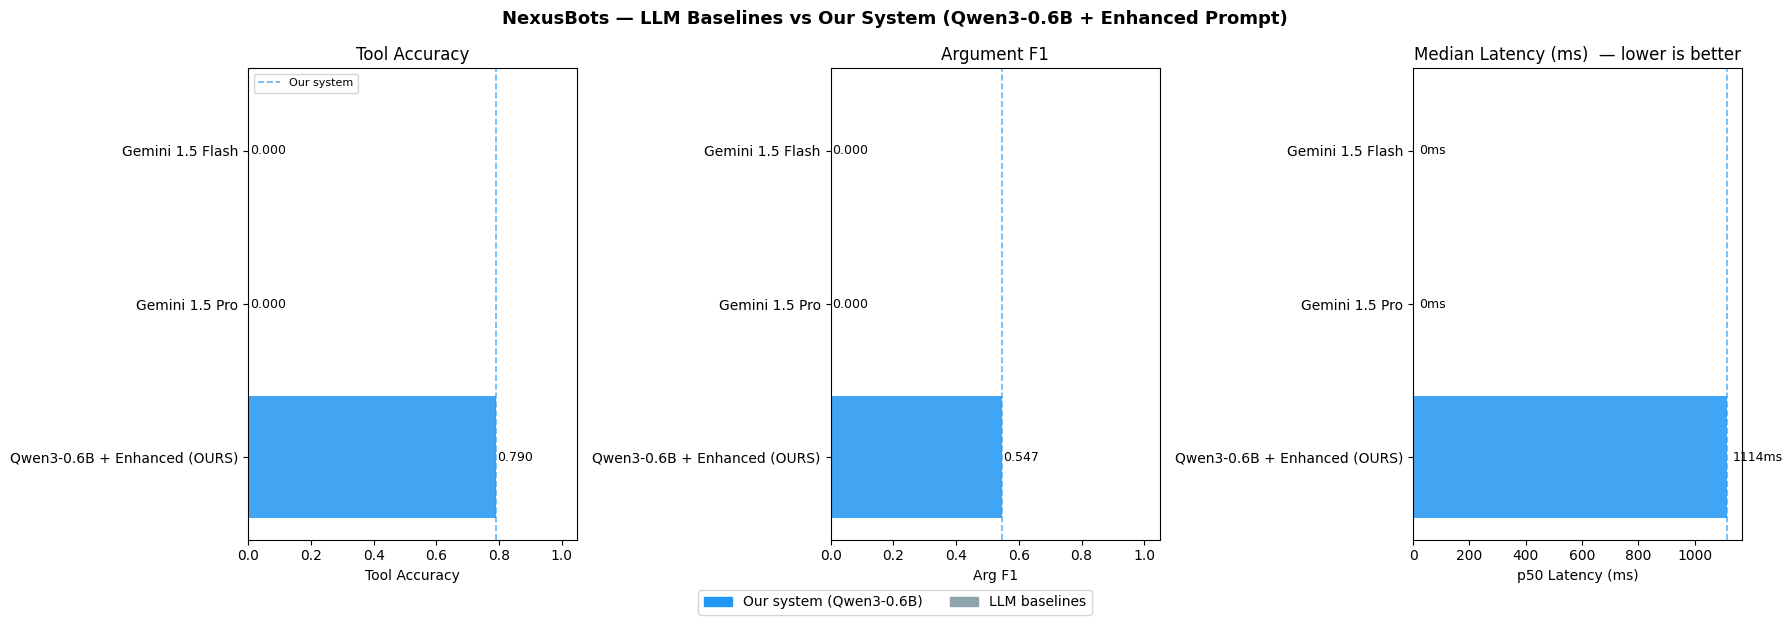

In [ ]:
df_plot = df.copy()

# Color: highlight our system
bar_colors = [
    "#2196F3" if "OURS" in row["system"] else "#90A4AE"
    for _, row in df_plot.iterrows()
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("NexusBots — LLM Baselines vs Our System (Qwen3-0.6B + Enhanced Prompt)",
             fontsize=13, fontweight="bold")

# ── Plot 1: Tool Accuracy ─────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(df_plot["system"], df_plot["tool_acc"], color=bar_colors, alpha=0.85)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Tool Accuracy")
ax.set_title("Tool Accuracy")
ax.axvline(0.79, color="#2196F3", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Our system")
for bar, val in zip(bars, df_plot["tool_acc"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
ax.legend(fontsize=8)

# ── Plot 2: Arg F1 ────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.barh(df_plot["system"], df_plot["arg_f1"], color=bar_colors, alpha=0.85)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Arg F1")
ax.set_title("Argument F1")
ax.axvline(0.5467, color="#2196F3", linestyle="--", linewidth=1.2, alpha=0.7)
for bar, val in zip(bars, df_plot["arg_f1"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

# ── Plot 3: Latency (p50) ─────────────────────────────────────────────────────
ax = axes[2]
bars = ax.barh(df_plot["system"], df_plot["p50_ms"], color=bar_colors, alpha=0.85)
ax.set_xlabel("p50 Latency (ms)")
ax.set_title("Median Latency (ms)  — lower is better")
ax.axvline(1113.8, color="#2196F3", linestyle="--", linewidth=1.2, alpha=0.7)
for bar, val in zip(bars, df_plot["p50_ms"]):
    ax.text(val + 20, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}ms", va="center", fontsize=9)

blue_patch  = mpatches.Patch(color="#2196F3", label="Our system (Qwen3-0.6B)")
gray_patch  = mpatches.Patch(color="#90A4AE", label="LLM baselines")
fig.legend(handles=[blue_patch, gray_patch], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
out_png = RESULTS_DIR / "llm_baseline_comparison.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
print(f"Saved → {out_png}")
plt.show()

## Cell 15 — Visualisation: Per-language tool accuracy heatmap

In [ ]:
if not df_lang.empty and len(ALL_RESULTS) > 0:
    pivot = df_lang.pivot_table(
        index="system", columns="language", values="tool_acc", aggfunc="first"
    )
    # Ensure EN / HI / TE columns
    for col in ["EN", "HI", "TE"]:
        if col not in pivot.columns:
            pivot[col] = np.nan
    pivot = pivot[["EN", "HI", "TE"]]

    fig, ax = plt.subplots(figsize=(7, max(4, len(pivot) * 0.6)))
    im = ax.imshow(pivot.values.astype(float), cmap="RdYlGn", vmin=0.4, vmax=1.0)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["EN", "HI", "TE"], fontsize=11)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title("Per-Language Tool Accuracy (green=better)", fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.03)

    for i in range(len(pivot)):
        for j in range(3):
            val = pivot.values[i, j]
            if not np.isnan(val):
                color = "white" if val < 0.6 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=10, color=color, fontweight="bold")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "llm_multilingual_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No results to plot — run Cell 9 first.")

## Cell 16 — Accuracy vs Cost scatter plot

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in df.iterrows():
    is_ours = "OURS" in row["system"]
    color   = "#2196F3" if is_ours else "#FF7043"
    marker  = "★" if is_ours else "o"
    size    = 200 if is_ours else 100
    ax.scatter(row["cost_usd"], row["tool_acc"], s=size, color=color,
               zorder=5, edgecolors="white", linewidths=1)
    ax.annotate(
        row["system"].replace(" (OURS)", " ★"),
        (row["cost_usd"], row["tool_acc"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
        color=color,
        fontweight="bold" if is_ours else "normal",
    )

ax.set_xlabel("API Cost for 100 calls (USD)", fontsize=11)
ax.set_ylabel("Tool Accuracy", fontsize=11)
ax.set_title("Accuracy vs Cost — Our System vs LLM Baselines", fontsize=12, fontweight="bold")
ax.set_ylim(0.4, 1.05)
ax.axhline(0.79, color="#2196F3", linestyle="--", linewidth=1, alpha=0.5,
           label="Our system accuracy")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate regions
ax.text(0.02, 0.97, "← Best region: high accuracy, low cost",
        transform=ax.transAxes, fontsize=8, color="gray", va="top")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 17 — Save all results

In [ ]:
# Overall summary
summary_csv = RESULTS_DIR / "llm_baseline_results.csv"
df.to_csv(summary_csv, index=False)
print(f"Saved summary        → {summary_csv}")

# Per-language
lang_csv = RESULTS_DIR / "llm_baseline_per_language.csv"
df_lang.to_csv(lang_csv, index=False)
print(f"Saved per-language   → {lang_csv}")

# Per-tool
tool_csv = RESULTS_DIR / "llm_baseline_per_tool.csv"
df_tools.to_csv(tool_csv, index=False)
print(f"Saved per-tool       → {tool_csv}")

# Per-row detail + failures for each model
for label, data in ALL_RESULTS.items():
    safe_name = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
    row_csv  = RESULTS_DIR / f"llm_{safe_name}_per_row.csv"
    fail_csv = RESULTS_DIR / f"llm_{safe_name}_failures.csv"
    pd.DataFrame(data["records"]).to_csv(row_csv, index=False)
    pd.DataFrame(data["fails"]).drop(columns=["raw_output"], errors="ignore").to_csv(fail_csv, index=False)
    print(f"  {label:<30} rows→{row_csv.name}  fails→{fail_csv.name}")

print(f"\nAll files saved to: {RESULTS_DIR}")

## Cell 18 — Final summary table

In [ ]:
print("\n" + "="*90)
print("  NEXUSBOTS — COMPLETE BENCHMARK SUMMARY")
print("="*90)
print(f"  Test set : {len(rows)} rows  |  Prompt : Enhanced (decision tree + 8 few-shots)")
print()
print(f"  {'System':<35} {'Tool Acc':>9} {'Arg F1':>8} {'UI Guide':>9} {'p50ms':>7} {'Cost/100':>10}")
print("  " + "-"*82)

for _, row in df.iterrows():
    marker = " ← OUR SYSTEM" if "OURS" in row["system"] else ""
    name   = row["system"].replace(" (OURS)", "")[:34].ljust(34)
    print(
        f"  {name}  "
        f"{row['tool_acc']:>9.4f}  "
        f"{row['arg_f1']:>7.4f}  "
        f"{row['ui_guide_acc']:>8.4f}  "
        f"{row['p50_ms']:>6.0f}ms  "
        f"${row['cost_usd']:>8.4f}"
        f"{marker}"
    )

print("  " + "-"*82)
print()
print("  Key finding:")
best_llm = df[df["system"] != QWEN_RESULT["system"]].iloc[0]
our_row  = df[df["system"] == QWEN_RESULT["system"]].iloc[0]
gap = best_llm["tool_acc"] - our_row["tool_acc"]
print(f"  Best LLM  : {best_llm['system']} → tool_acc={best_llm['tool_acc']:.4f}")
print(f"  Our system: Qwen3-0.6B + Enhanced   → tool_acc={our_row['tool_acc']:.4f}")
print(f"  Gap       : {gap:+.4f} ({gap*100:+.1f} pts) at ${our_row['cost_usd']:.4f} vs ${best_llm['cost_usd']:.4f} per 100 calls")
print("="*90)